In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

 Student Performance EDA

Анализ датасета успеваемости португальских студентов по математике.
Источник: UCI Machine Learning Repository
Цель: найти факторы влияющие на итоговую оценку G3.
Датасет: 395 студентов, 33 признака.

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')
print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


In [3]:
print(df.info())
print("\nПропуски")
print(df.isnull().sum())
print("\nСтатистика")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

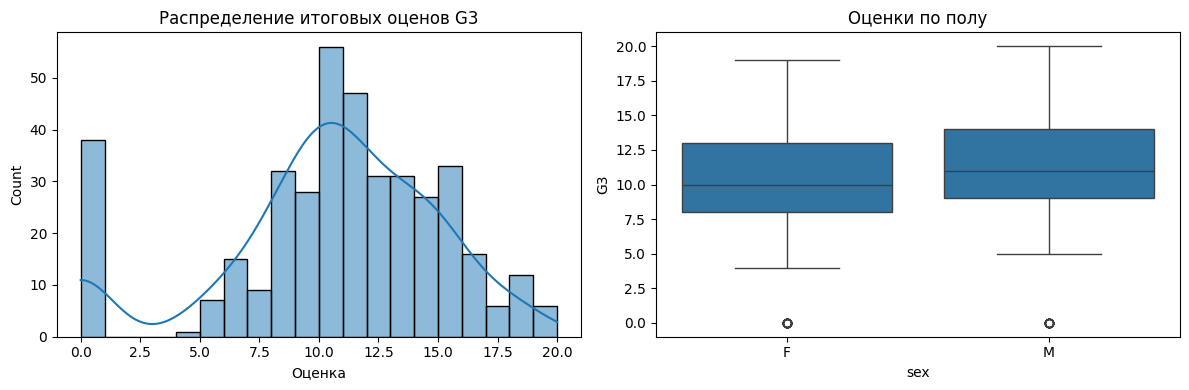

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Распределение итоговых оценов G3')
axes[0].set_xlabel("Оценка")

sns.boxplot(x='sex', y='G3', data=df, ax=axes[1])
axes[1].set_title('Оценки по полу')

plt.tight_layout()
plt.show()

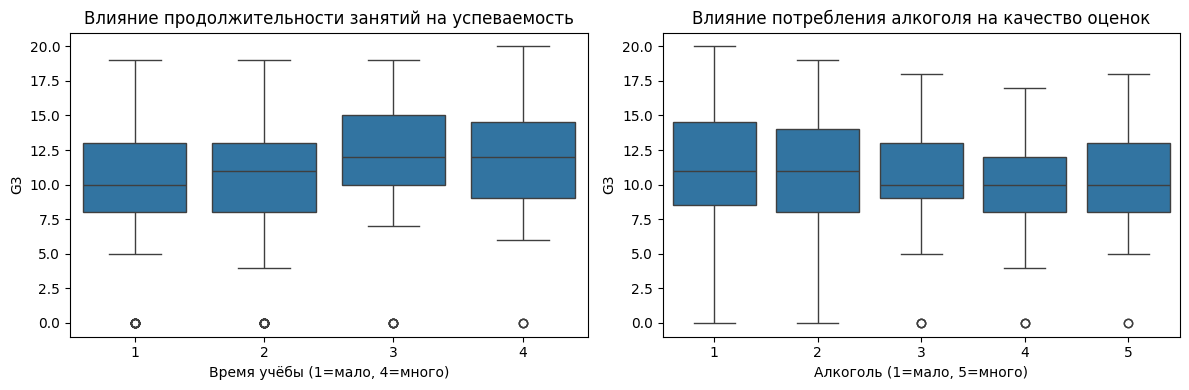

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0])
axes[0].set_title('Влияние продолжительности занятий на успеваемость')
axes[0].set_xlabel("Время учёбы (1=мало, 4=много)")

sns.boxplot(x='Walc', y='G3', data=df, ax=axes[1])
axes[1].set_title("Влияние потребления алкоголя на качество оценок")
axes[1].set_xlabel("Алкоголь (1=мало, 5=много)")

plt.tight_layout()
plt.show()

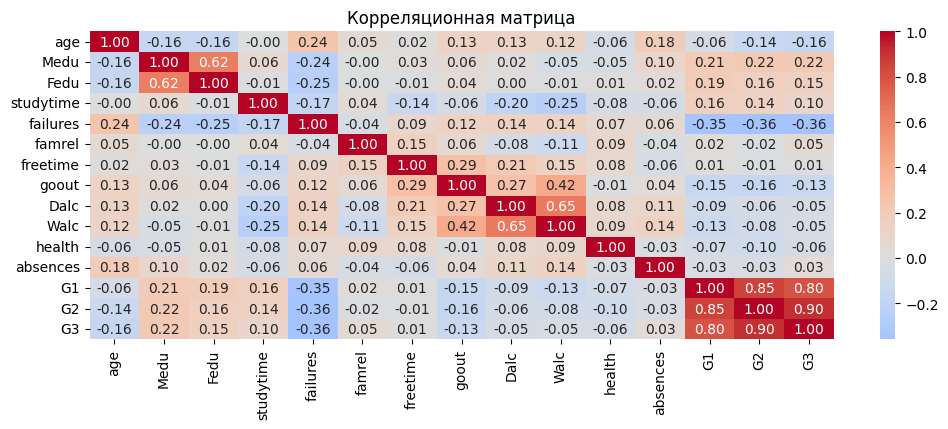

In [6]:
numeric_cols = ['age', 'Medu', 'Fedu', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 
                'health', 'absences', 'G1', 'G2', 'G3']

plt.figure(figsize=(12, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

In [7]:
print('===КЛЮЧЕВЫЕ ВЫВОДЫ===')
print(f'Число студентов: {len(df)}')
print(f"Средняя итоговая оценка G3: {df['G3'].mean():.1f}")
print('\nКорреляция с G3')
print(df[numeric_cols].corr()['G3'].sort_values(ascending=False).round(2))

===КЛЮЧЕВЫЕ ВЫВОДЫ===
Число студентов: 395
Средняя итоговая оценка G3: 10.4

Корреляция с G3
G3           1.00
G2           0.90
G1           0.80
Medu         0.22
Fedu         0.15
studytime    0.10
famrel       0.05
absences     0.03
freetime     0.01
Walc        -0.05
Dalc        -0.05
health      -0.06
goout       -0.13
age         -0.16
failures    -0.36
Name: G3, dtype: float64


   Выводы

- Средняя итоговая оценка: 10.4/20;
- Главный предиктор успеваемости — предыдущие оценки (G1, G2);
- Неудачи сильно снижают итоговую оценку;
- Оптимальное время учёбы 5-10 часов в неделю — оптимально;
- Алкоголь слабо влияет на оценки, но тренд отрицательный;
- ~10% студентов получили 0 — вероятно бросили курс'
- Мальчики в среднем чуть выше девочек по G3.